Imports + Setup

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import os
import json
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32

os.makedirs("../models",  exist_ok=True)
os.makedirs("../results", exist_ok=True)

XRAY_PATH  = "../data/xray_aug"
MODEL_P1   = "../models/resnet50_xray_phase1.pth"
MODEL_BEST = "../models/resnet50_xray_best.pth"
HISTORY_P1 = "../results/history_resnet50_xray_p1.json"
HISTORY_P2 = "../results/history_resnet50_xray_p2.json"

Device : cuda


DataLoaders

In [2]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

xray_train_loader = DataLoader(
    datasets.ImageFolder(f"{XRAY_PATH}/train", transform=transform),
    batch_size=BATCH_SIZE, shuffle=True
)
xray_val_loader = DataLoader(
    datasets.ImageFolder(f"{XRAY_PATH}/val", transform=transform),
    batch_size=BATCH_SIZE, shuffle=False
)
xray_test_loader = DataLoader(
    datasets.ImageFolder(f"{XRAY_PATH}/test", transform=transform),
    batch_size=BATCH_SIZE, shuffle=False
)

print("✅ DataLoaders X-Ray chargés !")
print(f"   Train  : {len(xray_train_loader.dataset)} images")
print(f"   Val    : {len(xray_val_loader.dataset)} images")
print(f"   Test   : {len(xray_test_loader.dataset)} images")
print(f"   Classes: {xray_train_loader.dataset.class_to_idx}")

✅ DataLoaders X-Ray chargés !
   Train  : 8658 images
   Val    : 699 images
   Test   : 1165 images
   Classes: {'NORMAL': 0, 'PNEUMONIA': 1}


Construire ResNet50

In [3]:
def build_resnet50_xray(device):
    model = models.resnet50(
        weights=models.ResNet50_Weights.IMAGENET1K_V1
    )

    # Geler toutes les couches
    for param in model.parameters():
        param.requires_grad = False

    # Remplacer dernière couche → 2 classes X-Ray
    in_features  = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.5),
        nn.Linear(512, 2)               # ← 2 classes
    )

    model = model.to(device)

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters()
                          if p.requires_grad)

    print(f"✅ ResNet50 X-Ray chargé !")
    print(f"   Total params     : {total_params:,}")
    print(f"   Trainable params : {trainable_params:,}")
    print(f"   Frozen params    : {total_params-trainable_params:,}")

    return model

resnet_xray = build_resnet50_xray(device)

✅ ResNet50 X-Ray chargé !
   Total params     : 24,558,146
   Trainable params : 1,050,114
   Frozen params    : 23,508,032


Loss, Optimizer, Scheduler

In [5]:
criterion_xray = nn.CrossEntropyLoss()

optimizer_xray = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_xray.parameters()),
    lr=1e-3
)

scheduler_xray = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_xray,
    mode='min', factor=0.5, patience=3
)

print("✅ Loss     : CrossEntropyLoss")
print("✅ Optimizer: Adam (lr=1e-3)")
print("✅ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)")

✅ Loss     : CrossEntropyLoss
✅ Optimizer: Adam (lr=1e-3)
✅ Scheduler: ReduceLROnPlateau (patience=3, factor=0.5)


Fonctions Train et Eval

In [6]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0

    for images, labels in tqdm(loader, desc="Train", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss    = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="Eval", leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss    = criterion(outputs, labels)

            total_loss += loss.item()
            preds       = outputs.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

Fonction Entraînement

In [7]:
def entrainer_modele(model, train_loader, val_loader,
                     criterion, optimizer, scheduler,
                     num_epochs, device,
                     save_path, history_path):

    historique = {
        'train_loss': [], 'train_acc': [],
        'val_loss'  : [], 'val_acc'  : []
    }

    meilleure_val_loss  = float('inf')
    patience_counter    = 0
    EARLY_STOP_PATIENCE = 7

    print(f"{'='*60}")
    print(f"  Début entraînement — {num_epochs} epochs max")
    print(f"  Modèle    : {save_path}")
    print(f"  Historique: {history_path}")
    print(f"{'='*60}\n")

    for epoch in range(num_epochs):

        train_loss, train_acc = train_epoch(
            model, train_loader, criterion, optimizer, device
        )
        val_loss, val_acc = eval_epoch(
            model, val_loader, criterion, device
        )

        scheduler.step(val_loss)

        historique['train_loss'].append(train_loss)
        historique['train_acc'].append(train_acc)
        historique['val_loss'].append(val_loss)
        historique['val_acc'].append(val_acc)

        # Sauvegarde JSON après chaque epoch
        with open(history_path, 'w') as f:
            json.dump(historique, f, indent=2)

        print(f"Epoch [{epoch+1:3d}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} "
              f"Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} "
              f"Val Acc: {val_acc:.4f}")

        if val_loss < meilleure_val_loss:
            meilleure_val_loss = val_loss
            patience_counter   = 0
            torch.save(model.state_dict(), save_path)
            print(f"  ✅ Meilleur modèle sauvegardé !")
        else:
            patience_counter += 1
            print(f"  ⚠️  Pas d'amélioration "
                  f"({patience_counter}/{EARLY_STOP_PATIENCE})")

        if patience_counter >= EARLY_STOP_PATIENCE:
            print(f"\n🛑 Early stopping epoch {epoch+1}")
            break

    print(f"\n{'='*60}")
    print(f"  Terminé ! Meilleure val_loss : {meilleure_val_loss:.4f}")
    print(f"{'='*60}")

    return historique

Phase 1 : Feature Extraction

In [8]:
print("PHASE 1 — Feature Extraction\n")

historique_p1 = entrainer_modele(
    model        = resnet_xray,
    train_loader = xray_train_loader,
    val_loader   = xray_val_loader,
    criterion    = criterion_xray,
    optimizer    = optimizer_xray,
    scheduler    = scheduler_xray,
    num_epochs   = 10,
    device       = device,
    save_path    = MODEL_P1,
    history_path = HISTORY_P1
)

PHASE 1 — Feature Extraction

  Début entraînement — 10 epochs max
  Modèle    : ../models/resnet50_xray_phase1.pth
  Historique: ../results/history_resnet50_xray_p1.json



Epoch [  1/10] Train Loss: 0.2163 Train Acc: 0.9123 | Val Loss: 0.1868 Val Acc: 0.9142
  ✅ Meilleur modèle sauvegardé !


Epoch [  2/10] Train Loss: 0.1860 Train Acc: 0.9274 | Val Loss: 0.1609 Val Acc: 0.9227
  ✅ Meilleur modèle sauvegardé !


Epoch [  3/10] Train Loss: 0.1591 Train Acc: 0.9367 | Val Loss: 0.1657 Val Acc: 0.9242
  ⚠️  Pas d'amélioration (1/7)


Epoch [  4/10] Train Loss: 0.1532 Train Acc: 0.9402 | Val Loss: 0.1856 Val Acc: 0.9170
  ⚠️  Pas d'amélioration (2/7)


...

Epoch [  6/10] Train Loss: 0.1352 Train Acc: 0.9481 | Val Loss: 0.1429 Val Acc: 0.9313
  ✅ Meilleur modèle sauvegardé !


Epoch [  7/10] Train Loss: 0.1432 Train Acc: 0.9449 | Val Loss: 0.1432 Val Acc: 0.9285
  ⚠️  Pas d'amélioration (1/7)


Epoch [  8/10] Train Loss: 0.1362 Train Acc: 0.9476 | Val Loss: 0.1467 Val Acc: 0.9342
  ⚠️  Pas d'amélioration (2/7)


Epoch [  9/10] Train Loss: 0.1285 Train Acc: 0.9516 | Val Loss: 0.1646 Val Acc: 0.9256
  ⚠️  Pas d'amélioration (3/7)


Epoch [ 10/10] Train Loss: 0.1218 Train Acc: 0.9544 | Val Loss: 0.1402 Val Acc: 0.9342
  ✅ Meilleur modèle sauvegardé !

  Terminé ! Meilleure val_loss : 0.1402


Phase 2 : Fine-Tuning

In [10]:
print("PHASE 2 — Fine-Tuning\n")

# Dégeler les 3 dernières couches
layers = list(resnet_xray.children())
for layer in layers[-3:]:
    for param in layer.parameters():
        param.requires_grad = True

trainable = sum(p.numel() for p in resnet_xray.parameters()
                if p.requires_grad)
print(f"Params entraînables après dégel : {trainable:,}\n")

optimizer_xray_ft = optim.Adam(
    filter(lambda p: p.requires_grad, resnet_xray.parameters()),
    lr=1e-5
)

scheduler_xray_ft = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_xray_ft,
    mode='min', factor=0.5, patience=3
)

historique_p2 = entrainer_modele(
    model        = resnet_xray,
    train_loader = xray_train_loader,
    val_loader   = xray_val_loader,
    criterion    = criterion_xray,
    optimizer    = optimizer_xray_ft,
    scheduler    = scheduler_xray_ft,
    num_epochs   = 3,
    device       = device,
    save_path    = MODEL_BEST,
    history_path = HISTORY_P2
)

PHASE 2 — Fine-Tuning

Params entraînables après dégel : 16,014,850

  Début entraînement — 3 epochs max
  Modèle    : ../models/resnet50_xray_best.pth
  Historique: ../results/history_resnet50_xray_p2.json



Epoch [  1/3] Train Loss: 0.0926 Train Acc: 0.9673 | Val Loss: 0.1064 Val Acc: 0.9514
  ✅ Meilleur modèle sauvegardé !


Epoch [  2/3] Train Loss: 0.0389 Train Acc: 0.9867 | Val Loss: 0.0942 Val Acc: 0.9642
  ✅ Meilleur modèle sauvegardé !


Epoch [  3/3] Train Loss: 0.0205 Train Acc: 0.9939 | Val Loss: 0.1028 Val Acc: 0.9628
  ⚠️  Pas d'amélioration (1/7)

  Terminé ! Meilleure val_loss : 0.0942


Visualiser courbes

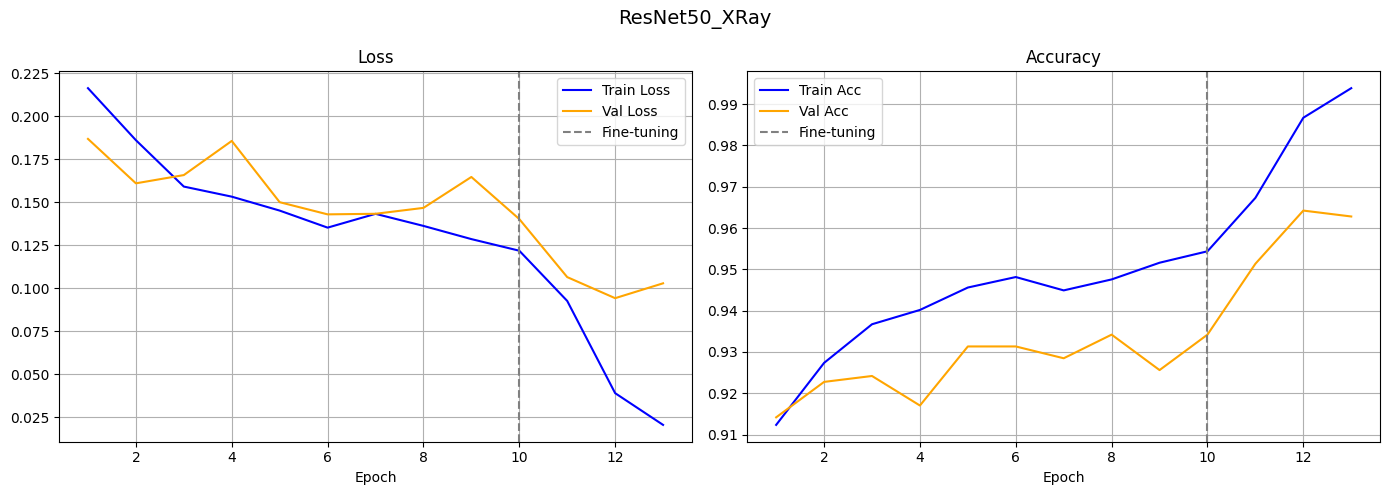


  Résumé — ResNet50_XRay
  Phase 1        : 10 epochs
  Phase 2        : 3 epochs
  Meilleure Val Loss : 0.0942
  Meilleure Val Acc  : 96.42%


In [11]:
def plot_depuis_json(path_p1, path_p2, titre):
    with open(path_p1, 'r') as f:
        hist1 = json.load(f)
    with open(path_p2, 'r') as f:
        hist2 = json.load(f)

    train_loss = hist1['train_loss'] + hist2['train_loss']
    val_loss   = hist1['val_loss']   + hist2['val_loss']
    train_acc  = hist1['train_acc']  + hist2['train_acc']
    val_acc    = hist1['val_acc']    + hist2['val_acc']
    epochs     = range(1, len(train_loss) + 1)
    sep        = len(hist1['train_loss'])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(titre, fontsize=14)

    axes[0].plot(epochs, train_loss, label='Train Loss', color='blue')
    axes[0].plot(epochs, val_loss,   label='Val Loss',   color='orange')
    axes[0].axvline(x=sep, color='gray',
                    linestyle='--', label='Fine-tuning')
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(epochs, train_acc, label='Train Acc', color='blue')
    axes[1].plot(epochs, val_acc,   label='Val Acc',   color='orange')
    axes[1].axvline(x=sep, color='gray',
                    linestyle='--', label='Fine-tuning')
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout()
    plt.savefig(f"../results/{titre}.png")
    plt.show()

    print(f"\n{'='*45}")
    print(f"  Résumé — {titre}")
    print(f"{'='*45}")
    print(f"  Phase 1        : {len(hist1['train_loss'])} epochs")
    print(f"  Phase 2        : {len(hist2['train_loss'])} epochs")
    print(f"  Meilleure Val Loss : {min(val_loss):.4f}")
    print(f"  Meilleure Val Acc  : {max(val_acc)*100:.2f}%")

plot_depuis_json(HISTORY_P1, HISTORY_P2, "ResNet50_XRay")

Évaluation Test Set

Test: 100%|██████████| 37/37 [00:33<00:00,  1.10it/s]


  ÉVALUATION — ResNet50 X-Ray
              precision    recall  f1-score   support

      NORMAL       0.94      0.92      0.93       316
   PNEUMONIA       0.97      0.98      0.97       849

    accuracy                           0.96      1165
   macro avg       0.96      0.95      0.95      1165
weighted avg       0.96      0.96      0.96      1165

AUC-ROC : 0.9906


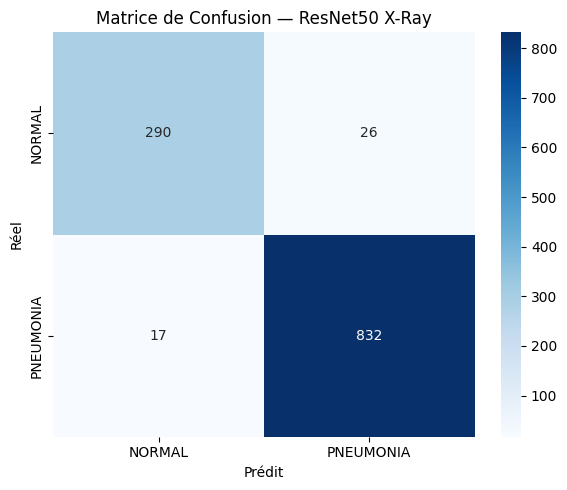

✅ Métriques sauvegardées !


In [12]:
from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              roc_auc_score)
import seaborn as sns

# Charger meilleur modèle
resnet_xray.load_state_dict(
    torch.load(MODEL_BEST, map_location=device)
)
resnet_xray.eval()

all_preds  = []
all_labels = []
all_probs  = []

with torch.no_grad():
    for images, labels in tqdm(xray_test_loader, desc="Test"):
        images  = images.to(device)
        outputs = resnet_xray(images)
        probs   = torch.softmax(outputs, dim=1)
        preds   = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)
classes    = list(xray_test_loader.dataset.class_to_idx.keys())

# Métriques
print("=" * 55)
print("  ÉVALUATION — ResNet50 X-Ray")
print("=" * 55)
print(classification_report(all_labels, all_preds,
                             target_names=classes))

auc = roc_auc_score(all_labels, all_probs[:, 1])
print(f"AUC-ROC : {auc:.4f}")

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=classes,
            yticklabels=classes,
            cmap='Blues')
plt.title("Matrice de Confusion — ResNet50 X-Ray")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.tight_layout()
plt.savefig("../results/confusion_resnet50_xray.png")
plt.show()

# Sauvegarder métriques
metriques = {
    "model"   : "ResNet50",
    "dataset" : "X-Ray",
    "accuracy": float((all_preds == all_labels).mean()),
    "auc_roc" : float(auc),
    "classes" : classes
}

with open("../results/metriques_resnet50_xray.json", "w") as f:
    json.dump(metriques, f, indent=2)

print("✅ Métriques sauvegardées !")